In [27]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
data = pd.read_csv('UberDataset.csv')

In [29]:
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [31]:
data.shape

(1156, 7)

In [32]:
data.isnull().sum()

START_DATE      0
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64

In [33]:
data['PURPOSE'].fillna("NOT", inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_11176\2886046430.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['PURPOSE'].fillna("NOT", inplace=True)


In [34]:

data['START_DATE'] = pd.to_datetime(data['START_DATE'], errors='coerce')

In [35]:
data['END_DATE'] = pd.to_datetime(data['END_DATE'], errors='coerce')

In [36]:
data['MONTH'] = data['START_DATE'].dt.month_name()
data['DAY_OF_WEEK'] = data['START_DATE'].dt.day_name()
data['HOUR'] = data['START_DATE'].dt.hour

In [37]:
from datetime import datetime
data['data'] = pd.DatetimeIndex(data['START_DATE']).date
data['time'] = pd.DatetimeIndex(data['START_DATE']).hour

In [38]:
data['day-night'] = pd.cut(x=data['time'],bins = [0,10,15,19,24],labels = ['Morning','Afternoon','Evening','Night'] )

In [39]:
data.dropna(inplace=True)

In [40]:
data.drop_duplicates(inplace=True)

In [41]:
obj = (data.dtypes == 'object')
object_cols = list(obj[obj].index)

unique_values = {}
for col in object_cols:
  unique_values[col] = data[col].unique().size
unique_values

{'CATEGORY': 2,
 'START': 108,
 'STOP': 112,
 'PURPOSE': 7,
 'MONTH': 12,
 'DAY_OF_WEEK': 7,
 'data': 113}

<Axes: xlabel='count', ylabel='CATEGORY'>

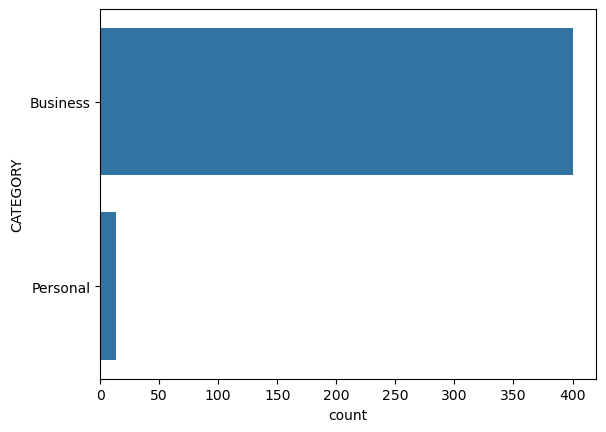

In [42]:
sns.countplot(data['CATEGORY'])

<Axes: xlabel='count', ylabel='PURPOSE'>

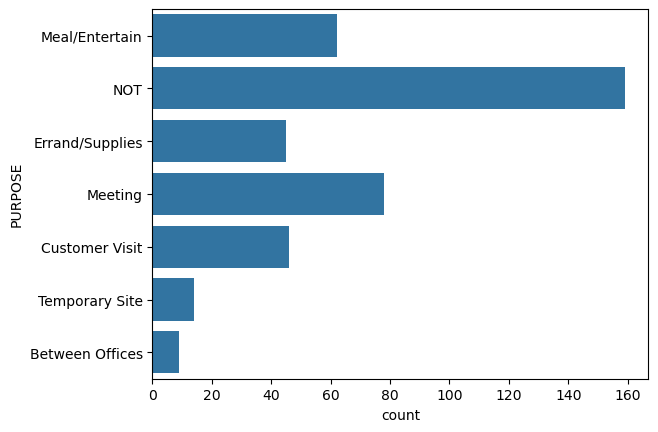

In [43]:
sns.countplot(data['PURPOSE'])

<Axes: xlabel='count', ylabel='day-night'>

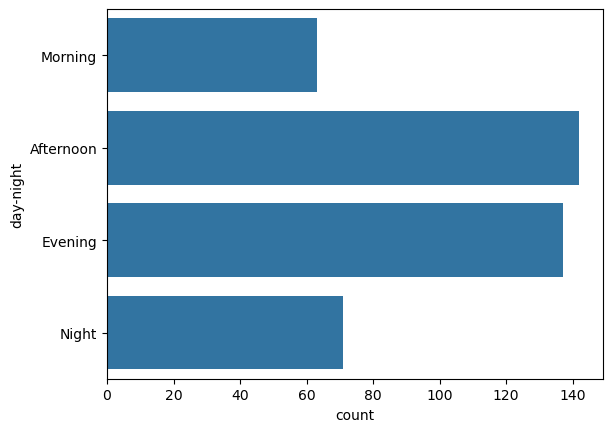

In [44]:
sns.countplot(data['day-night'])

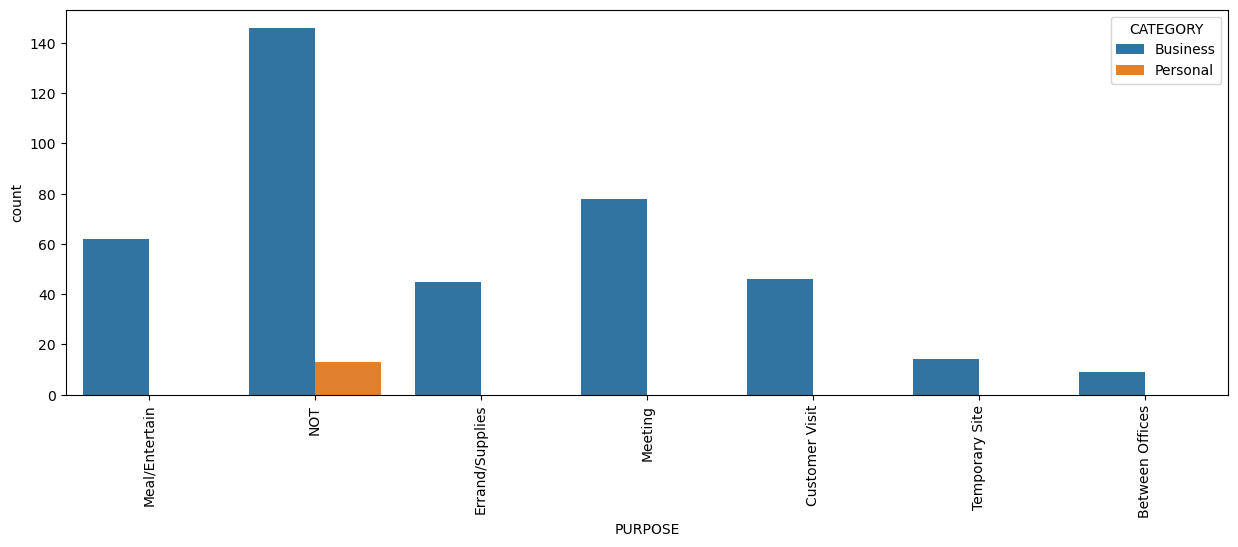

In [45]:
plt.figure(figsize=(15, 5))
sns.countplot(data=data, x='PURPOSE', hue='CATEGORY')
plt.xticks(rotation=90)
plt.show()

[Text(0.5, 0, 'MONTHS'), Text(0, 0.5, 'VALUE COUNT')]

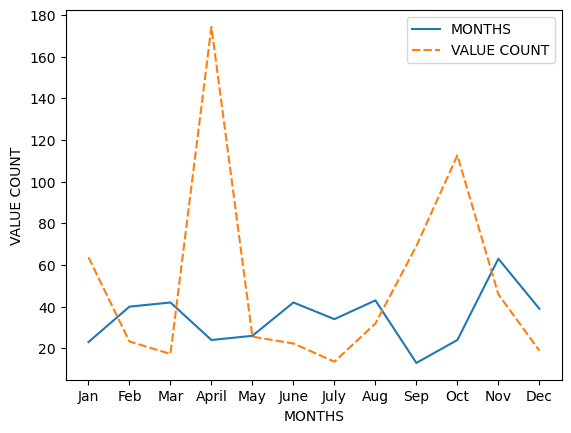

In [46]:
data['MONTH'] = pd.DatetimeIndex(data['START_DATE']).month
month_label = {1.0: 'Jan', 2.0: 'Feb', 3.0: 'Mar', 4.0: 'April',
               5.0: 'May', 6.0: 'June', 7.0: 'July', 8.0: 'Aug',
               9.0: 'Sep', 10.0: 'Oct', 11.0: 'Nov', 12.0: 'Dec'}
data["MONTH"] = data.MONTH.map(month_label)

mon = data.MONTH.value_counts(sort=False)

# Month total rides count vs Month ride max count
data = pd.DataFrame({"MONTHS": mon.values,
                   "VALUE COUNT": data.groupby('MONTH',
                                                  sort=False)['MILES'].max()})

p = sns.lineplot(data=data)
p.set(xlabel="MONTHS", ylabel="VALUE COUNT")

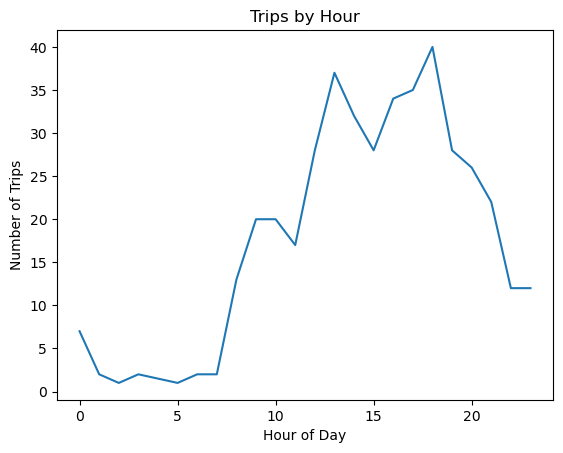

In [48]:
data = pd.read_csv("UberDataset.csv")

data["START_DATE"] = pd.to_datetime(data["START_DATE"], errors='coerce')
data["Hour"] = data["START_DATE"].dt.hour

hourly_counts = data["Hour"].value_counts().sort_index()

plt.figure()
plt.plot(hourly_counts.index, hourly_counts.values)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Trips by Hour")
plt.show()

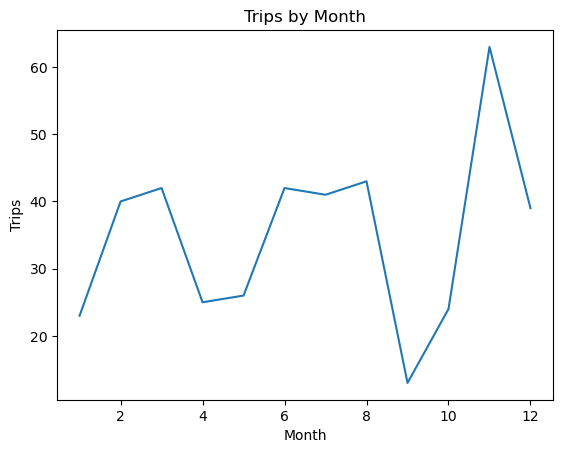

In [49]:
data["Month"] = data["START_DATE"].dt.month
monthly_counts = data["Month"].value_counts().sort_index()
plt.figure()
plt.plot(monthly_counts.index, monthly_counts.values)
plt.xlabel("Month")
plt.ylabel("Trips")
plt.title("Trips by Month")
plt.show()

In [50]:
data["Day"] = data["START_DATE"].dt.dayofweek
data["Weekend"] = data["Day"].apply(lambda x: 1 if x>=5 else 0)

pd.crosstab(data["CATEGORY"], data["Weekend"])

Weekend,0,1
CATEGORY,,
Business,983,95
Personal,72,5


In [51]:
y = lambda x: 1 if x>=5 else 0
print(y(7))

1


In [52]:
data["END_DATE"] = pd.to_datetime(data["END_DATE"], errors='coerce')
data["Duration"] = (data["END_DATE"] - data["START_DATE"]).dt.total_seconds()/60

data["Duration"].mean()

np.float64(19.326190476190476)

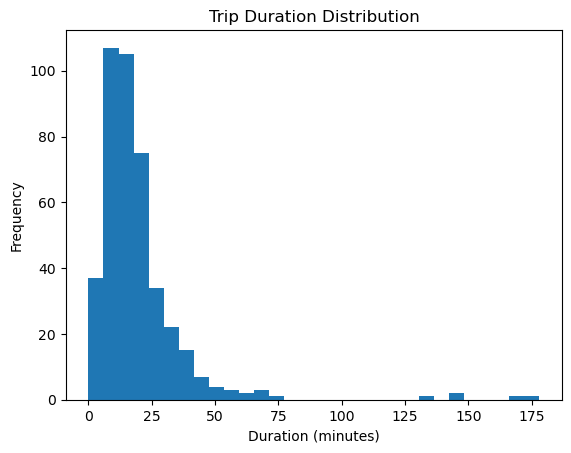

In [54]:
plt.figure()
plt.hist(data["Duration"], bins=30)
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.title("Trip Duration Distribution")
plt.show()


In [56]:
data.groupby("CATEGORY")["MILES"].mean()

CATEGORY
Business    10.655844
Personal     9.320779
Name: MILES, dtype: float64

In [58]:
data["START"].value_counts().head(10)

START
Cary                201
Unknown Location    148
Morrisville          85
Whitebridge          68
Islamabad            57
Durham               37
Lahore               36
Raleigh              28
Kar?chi              27
Westpark Place       17
Name: count, dtype: int64

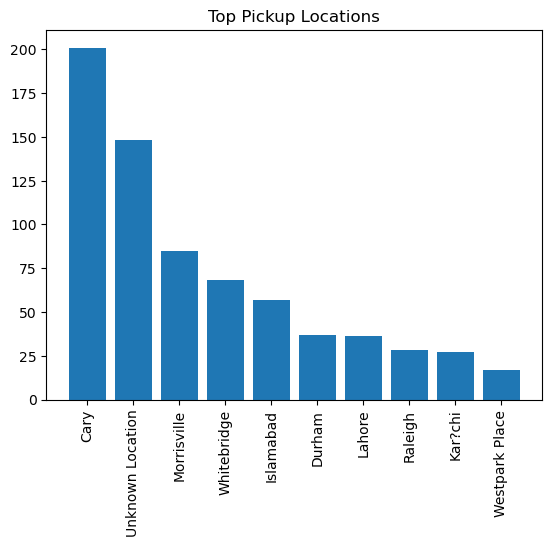

In [59]:
city_counts = data["START"].value_counts().head(10)

plt.figure()
plt.bar(city_counts.index, city_counts.values)
plt.xticks(rotation=90)
plt.title("Top Pickup Locations")
plt.show()

In [63]:
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

le = LabelEncoder()
data["START_encoded"] = le.fit_transform(data["START"])

kmeans = KMeans(n_clusters=3)
data["Cluster"] = kmeans.fit_predict(data[["START_encoded", "MILES"]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


In [64]:
data["Route"] = data["START"] + " → " + data["STOP"]
data["Route"].value_counts().head(10)

Route
Unknown Location → Unknown Location    86
Morrisville → Cary                     75
Cary → Morrisville                     67
Cary → Cary                            53
Cary → Durham                          36
Durham → Cary                          32
Unknown Location → Islamabad           28
Islamabad → Unknown Location           28
Lahore → Lahore                        27
Islamabad → Islamabad                  25
Name: count, dtype: int64

In [65]:
data[data["PURPOSE"]=="Meal/Entertain"]["Route"].value_counts().head()

Route
Cary → Morrisville           27
Morrisville → Cary           18
Cary → Cary                  12
Lahore → Lahore               6
Whitebridge → Wayne Ridge     4
Name: count, dtype: int64

In [66]:
data["PURPOSE"]

0        Meal/Entertain
1                   NaN
2       Errand/Supplies
3               Meeting
4        Customer Visit
             ...       
1151     Temporary Site
1152            Meeting
1153     Temporary Site
1154     Temporary Site
1155                NaN
Name: PURPOSE, Length: 1156, dtype: object

In [67]:
data["MILES"].mean()

np.float64(21.115397923875435)

In [68]:
import numpy as np

Q1 = data["MILES"].quantile(0.25)
Q3 = data["MILES"].quantile(0.75)
IQR = Q3 - Q1
outliers = data[data["MILES"] > Q3 + 1.5*IQR]


In [69]:
data[["MILES","Duration"]].corr()

,MILES,Duration
MILES,1.000000,0.746342
Duration,0.746342,1.000000


In [70]:
data["PURPOSE"].value_counts()

PURPOSE
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Commute              1
Charity ($)          1
Name: count, dtype: int64

In [71]:
data[data["PURPOSE"]=="Airport/Travel"]["MILES"].mean()

np.float64(5.5)

In [ ]:
data.groupby("C")